In [7]:
#cell 1
# ================= WINDOWS SAFETY FIX =================
import multiprocessing
multiprocessing.freeze_support()

# ================= IMPORTS =================
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# ================= CONFIGURATION =================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Create folders
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


Found 1695 files belonging to 4 classes.
Found 502 files belonging to 4 classes.
Found 246 files belonging to 4 classes.

Class Names:
['glioma', 'meningioma', 'no_tumor', 'pituitary']

Number of Classes: 4

Training Set Distribution:
glioma : 564
meningioma : 358
no_tumor : 335
pituitary : 438


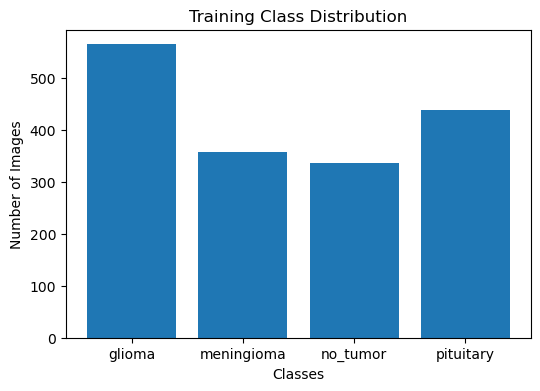

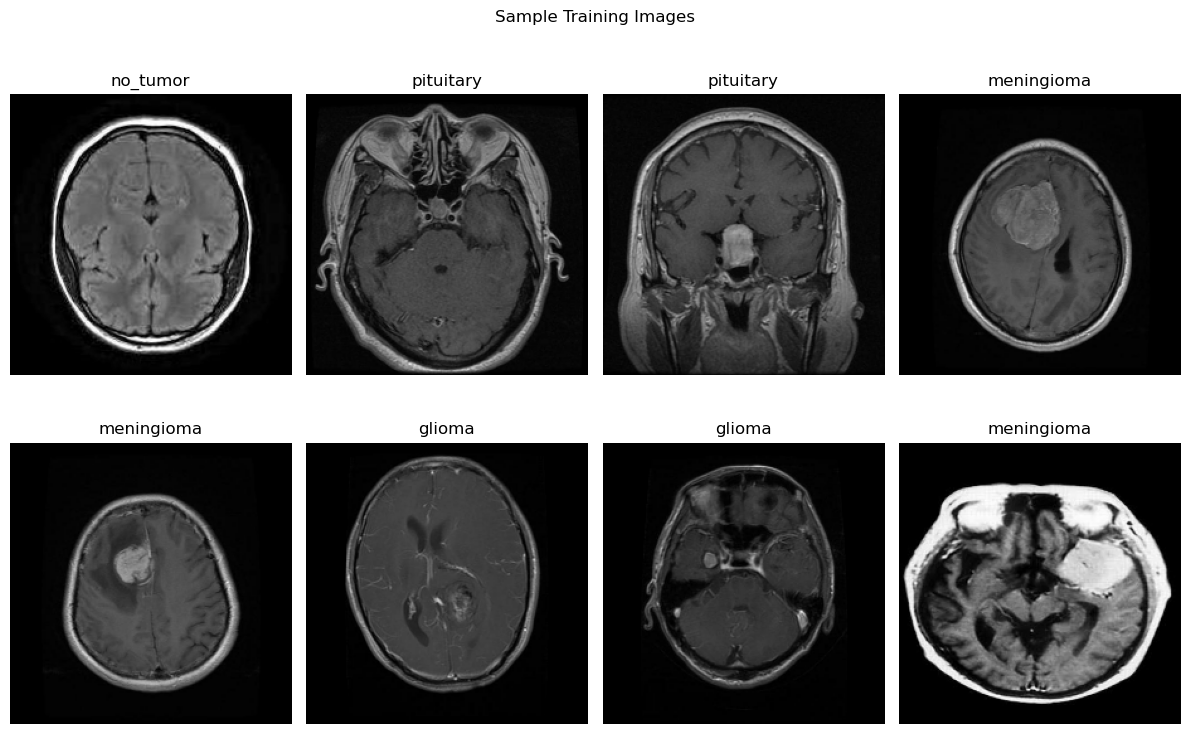


Original Image Size Distribution:
(640, 640) : 80

EDA Completed Successfully ✅
Dataset shows moderate class imbalance.
Transfer learning and augmentation will help reduce bias.


In [11]:
#cell 2
# ================= LOAD DATASETS =================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ================= CLASS INFORMATION =================
class_names = train_ds.class_names
num_classes = len(class_names)

print("\nClass Names:")
print(class_names)

print("\nNumber of Classes:", num_classes)

# Save class names for Streamlit
np.save("models/class_names.npy", class_names)

# ================= CLASS DISTRIBUTION =================
train_labels = np.concatenate([y.numpy() for _, y in train_ds])

distribution = Counter(train_labels)

print("\nTraining Set Distribution:")

for idx, count in sorted(distribution.items()):
    print(f"{class_names[idx]} : {count}")

# Visualize class distribution
plt.figure(figsize=(6,4))

plt.bar(
    [class_names[i] for i in distribution.keys()],
    distribution.values()
)

plt.title("Training Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Classes")

plt.show()

# ================= SAMPLE IMAGES =================
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(min(8, len(images))):

        plt.subplot(2, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.suptitle("Sample Training Images")

plt.tight_layout()

plt.savefig(
    "results/sample_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
# ================= ORIGINAL IMAGE SIZE CHECK =================
sizes = []

for class_name in class_names:

    folder = os.path.join("data/train", class_name)

    files = os.listdir(folder)

    for file in files[:20]:  # check first 20 images per class

        path = os.path.join(folder, file)

        try:
            img = Image.open(path)

            sizes.append(img.size)

        except:
            pass

print("\nOriginal Image Size Distribution:")

for size, count in Counter(sizes).items():
    print(f"{size} : {count}")

print("\nEDA Completed Successfully ✅")

print("Dataset shows moderate class imbalance.")
print("Transfer learning and augmentation will help reduce bias.")

In [12]:
print(train_ds.class_names)
print(valid_ds.class_names)
print(test_ds.class_names)

['glioma', 'meningioma', 'no_tumor', 'pituitary']
['glioma', 'meningioma', 'no_tumor', 'pituitary']
['glioma', 'meningioma', 'no_tumor', 'pituitary']


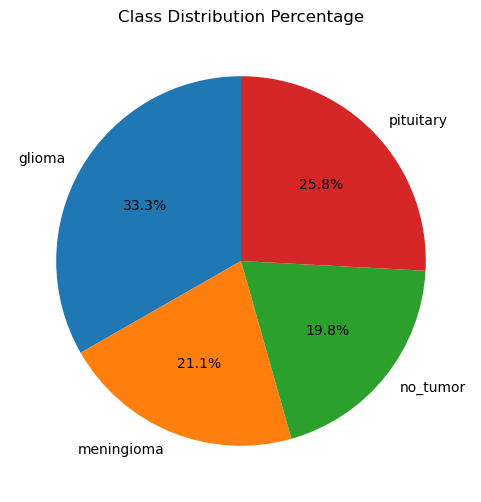

In [13]:
#cell 3
plt.figure(figsize=(6,6))

plt.pie(
    distribution.values(),
    labels=class_names,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Class Distribution Percentage")

plt.savefig(
    "results/class_distribution_pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
#cell 4
# ================= DATA PIPELINE =================
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# ================= PREPROCESSING =================
normalization = tf.keras.layers.Rescaling(1./255)

# ================= DATA AUGMENTATION =================
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.05),

    tf.keras.layers.RandomZoom(0.05),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    tf.keras.layers.RandomContrast(0.05)
])

print("Preprocessing & Augmentation Ready ✅")

Preprocessing & Augmentation Ready ✅


In [15]:
#cell 5
# ================= CUSTOM CNN =================
custom_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224,224,3)),

    augmentation,
    normalization,

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_model.summary()
print("\nInput Shape:", custom_model.input_shape)
print("Output Shape:", custom_model.output_shape)

# ================= CALLBACKS =================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "models/custom_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    )
]

# ================= TRAIN =================
history_custom = custom_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ================= SAVE FINAL MODEL =================
custom_model.save("models/custom_cnn_final.keras")

print("\nCustom CNN Saved Successfully ✅")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 222, 222, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 109, 109, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 52, 52, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 439,428 (1.68 MB)

 Trainable params: 438,532 (1.67 MB)

 Non-trainable params: 896 (3.50 KB)


Input Shape: (None, 224, 224, 3)
Output Shape: (None, 4)
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - accuracy: 0.6472 - loss: 0.9248 - val_accuracy: 0.2450 - val_loss: 1.3847 - learning_rate: 1.0000e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - accuracy: 0.7097 - loss: 0.7654 - val_accuracy: 0.1753 - val_loss: 1.4275 - learning_rate: 1.0000e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7288 - loss: 0.7019
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
53/53 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - accuracy: 0.7451 - loss: 0.6893 - val_accuracy: 0.1952 - val_loss: 1.5344 - learning_rate: 1.0000e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.7510 - loss: 0.6711 - val_accuracy: 0.1534 - val_loss: 1.6526 - learning_rate: 2.0000e-05
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7456 - loss: 0.6658
Epoch 5: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
53/53 ━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 770ms/step - accuracy: 0.2317 - loss: 1.3864
Test Accuracy: 0.23170731961727142
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 873ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.05      0.06      0.06        49
   pituitary       0.29      1.00      0.45        54

    accuracy                           0.23       246
   macro avg       0.09      0.27      0.13       246
weighted avg       0.07      0.23      0.11       246


Confusion Matrix:

[[ 0  0 42 38]
 [ 0  0 15 48]
 [ 0  0  3 46]
 [ 0  0  0 54]]


C:\Users\sooda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sooda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sooda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


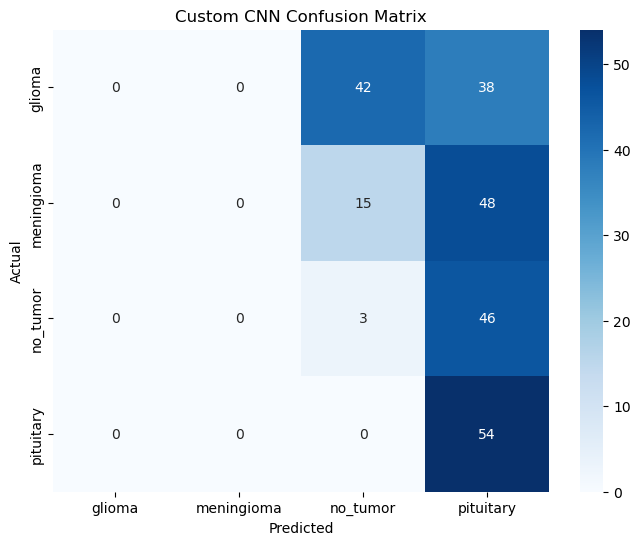

In [16]:
#cell 6
# ================= TEST EVALUATION =================

loss, acc = custom_model.evaluate(test_ds)

print("Test Accuracy:", acc)

# True labels
y_true = np.concatenate([y.numpy() for _, y in test_ds])

# Predictions
y_pred = np.argmax(
    custom_model.predict(test_ds),
    axis=1
)

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Custom CNN Confusion Matrix")

plt.show()

In [17]:
#cell 7

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# EfficientNet preprocessing
train_tl = train_ds.map(lambda x, y: (preprocess_input(x), y))
valid_tl = valid_ds.map(lambda x, y: (preprocess_input(x), y))
test_tl  = test_ds.map(lambda x, y: (preprocess_input(x), y))

# Base model
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Classification head
inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)

x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(
    num_classes,
    activation="softmax"
)(x)

eff_model = tf.keras.Model(inputs, outputs)

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "models/efficientnet_final.keras",
        save_best_only=True
    )
]

# Train classifier head
history_eff = eff_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=10,
    callbacks=callbacks
)

# Fine tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = eff_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=5,
    callbacks=callbacks
)

eff_model.save("models/efficientnet_final.keras")

print("EfficientNet Saved Successfully ✅")

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 66s 947ms/step - accuracy: 0.5221 - loss: 1.1365 - val_accuracy: 0.7092 - val_loss: 0.8155
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 942ms/step - accuracy: 0.7363 - loss: 0.7396 - val_accuracy: 0.7908 - val_loss: 0.6130
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 864ms/step - accuracy: 0.7953 - loss: 0.5840 - val_accuracy: 0.8068 - val_loss: 0.5357
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 831ms/step - accuracy: 0.8230 - loss: 0.4870 - val_accuracy: 0.8327 - val_loss: 0.4560
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 831ms/step - accuracy: 0.8437 - loss: 0.4397 - val_accuracy: 0.8546 - val_loss: 0.4072
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 852ms/step - accuracy: 0.8684 - loss: 0.3968 - val_accuracy: 0.8625 - val_loss: 0.3779
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 825ms/step - accuracy: 0.8767 - loss: 0.3772 - val_accuracy: 0.8765 - val_loss: 0.3616
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 861ms/step - accuracy: 0.8732 - loss: 0.3440 - val_accu

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 555ms/step - accuracy: 0.8659 - loss: 0.3696
EfficientNet Test Accuracy: 0.8658536672592163
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 578ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.83      0.96      0.89        80
  meningioma       0.81      0.70      0.75        63
    no_tumor       0.95      0.82      0.88        49
   pituitary       0.91      0.96      0.94        54

    accuracy                           0.87       246
   macro avg       0.88      0.86      0.86       246
weighted avg       0.87      0.87      0.86       246


Confusion Matrix:

[[77  3  0  0]
 [12 44  2  5]
 [ 3  6 40  0]
 [ 1  1  0 52]]


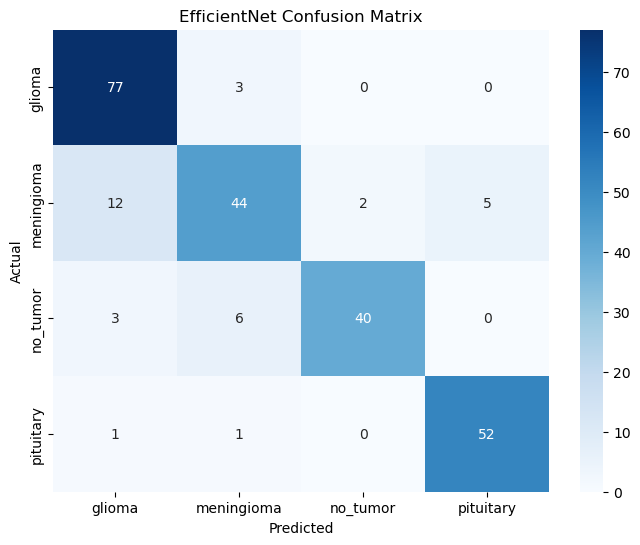

In [19]:
loss, acc = eff_model.evaluate(test_tl)

print("EfficientNet Test Accuracy:", acc)

y_true = np.concatenate([y.numpy() for _, y in test_tl])

y_pred = np.argmax(
    eff_model.predict(test_tl),
    axis=1
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EfficientNet Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "results/efficientnet_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

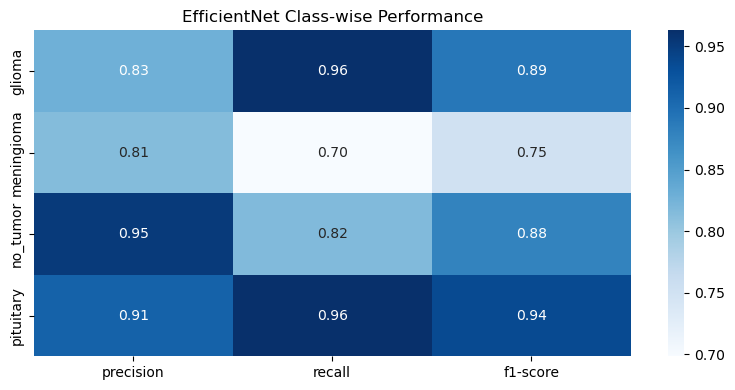

In [21]:
# ================= CLASS-WISE METRICS HEATMAP =================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

metrics_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))

metrics_df = metrics_df.loc[
    class_names,
    ["precision", "recall", "f1-score"]
]

sns.heatmap(
    metrics_df,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("EfficientNet Class-wise Performance")

plt.tight_layout()

plt.savefig(
    "results/classwise_metrics_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 540ms/step
          Model  Accuracy  Precision    Recall  F1 Score
0    Custom CNN  0.231707   0.073689  0.231707  0.109745
1  EfficientNet  0.865854   0.867885  0.865854  0.862886


C:\Users\sooda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


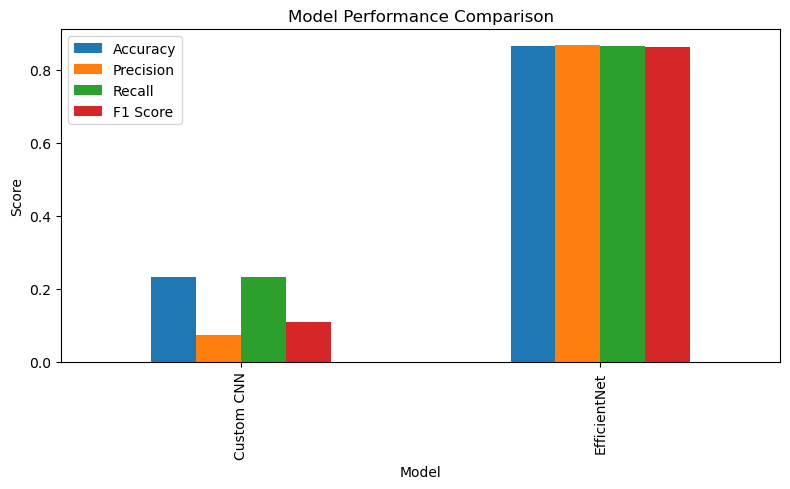


Project Completed Successfully ✅


In [24]:
cnn_loss, cnn_acc = custom_model.evaluate(
    test_ds,
    verbose=0
)

eff_loss, eff_acc = eff_model.evaluate(
    test_tl,
    verbose=0
)

precision_cnn, recall_cnn, f1_cnn, _ = precision_recall_fscore_support(
    y_true,
    np.argmax(custom_model.predict(test_ds), axis=1),
    average="weighted"
)

precision_eff, recall_eff, f1_eff, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

metrics = pd.DataFrame({
    "Model": ["Custom CNN", "EfficientNet"],
    "Accuracy": [cnn_acc, eff_acc],
    "Precision": [precision_cnn, precision_eff],
    "Recall": [recall_cnn, recall_eff],
    "F1 Score": [f1_cnn, f1_eff]
})

print(metrics)

metrics.to_csv(
    "results/metrics.csv",
    index=False
)

metrics.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Score")

plt.title("Model Performance Comparison")

plt.tight_layout()

plt.savefig("results/model_comparison.png")

plt.show()

print("\nProject Completed Successfully ✅")